# Video: Visualizing Bias and Variance

In this video, we will visualize the bias and variance of linear models on a synthetic data set.

[![View on GitHub](https://img.shields.io/badge/GitHub-181717?logo=github&logoColor=white)](https://github.com/bu-cds-omds/dx601-examples/blob/main/week14/video_visualizing_bias_and_variance.ipynb)
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bu-cds-omds/dx601-examples/blob/main/week14/video_visualizing_bias_and_variance.ipynb)



Script: (faculty on screen)
* Bias and variance are important concepts for understanding a modeling process.
* Bias quantifies how much the modeling process systematically over or underestimates a prediction, while variance quantifies how much predictions vary as the modeling process is repeated.

## Modeling Problem

Let $f(x)$ be the ground truth expected value for input $x$.
* For an input $x_i$, output $y_i = f(x_i) + \epsilon_i$.
* $\epsilon_i$ is a random variable with mean 0.

Given training data $D$, then
* $\hat{f}(x; D)$ will be the modeled prediction for input $x$.

Script:
* Bias and variance are defined in terms of the expected value of a process and its noise.
* We will call the expected value $f(x)$ and the noise $\epsilon$.
* The goal of modeling will be to estimate $f(x)$ as the noise is inherently unpredictable.
* The modeling process will take in training data $D$ to compute the model.
* We will call its prediction for input $x$ after training on $D$ $\hat{f}(x; D)$.
* We will want $f$ and $\hat{f}$ to have similar outputs for the same $x$, but we will see that relationship will depend on the modeling process and which training data is used.

## Definitions

$\mathrm{Bias}_D \left[ \hat{f}(x; D) \right] = \mathbb{E}_D \left[ \hat{f}(x; D) - f(x) \right]$

$\mathrm{Var}_D \left[ \hat{f}(x; D) \right] = \mathbb{E}_D \left[ \left( \hat{f}(x; D) - \mathbb{E}_D [ \hat{f}(x; D) ] \right)^2 \right]$

Script:
* The bias is the expected difference between the model predictions and the ground truth expected value.
* The variance of the modeling process is the variance in those predictions.
* They are similar to calculating the mean and variance.
* But these expectations are over the distribution of training data samples, rather than over rows of a data set.
* If many training data sets were gathered, what would be the expected difference between the predicted value and the actual expected value?
* That is the bias of the modeling process.
* If it is positive, then the predictions are biased high.
* If it is negative, then the predictions are biased low.
* An important detail to notice is that these bias and variance measures are evaluating the modeling process on a single input $x$.

## Synthetic Sample Data


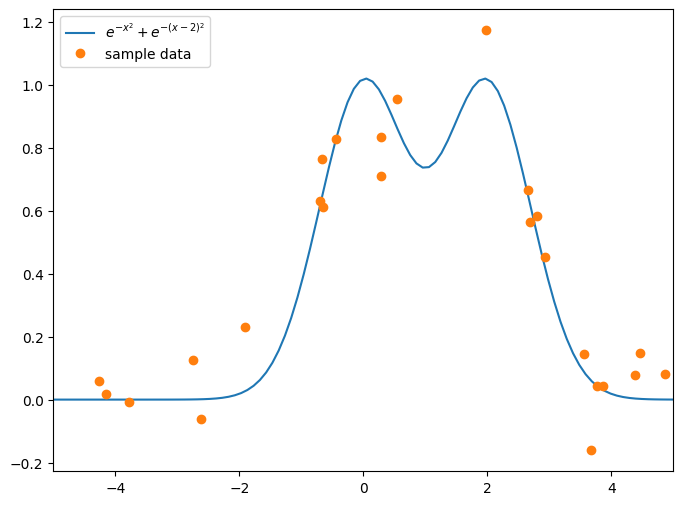

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

formula = "e^{-x^2} + e^{-(x-2)^2}"

def f(x):
    return np.exp(-x**2) + np.exp(-(x - 2)**2)

def sample(n):
    xs = np.random.uniform(low=-5, high=5, size=n)
    ys = f(xs) + np.random.normal(scale=0.1, size=n)
    return xs, ys

xs_truth = np.linspace(-5, 5, 100)
ys_truth = f(xs_truth)

np.random.seed(42_14_1)
xs_train, ys_train = sample(25)

plt.figure(figsize=(8, 6))

plt.plot(xs_truth, ys_truth, label=f"${formula}$")
plt.plot(xs_train, ys_train, 'o', label=f"sample data")

plt.legend(loc="upper left")
plt.xlim(xs_truth.min(), xs_truth.max())

plt.show()

Script:
* To show off the concepts of bias and variance, we will test with this synthetic function where we can generate as much data as we like.
* This function was chosen to be hard for linear models.
* A linear model will not be able to fit the left, middle, and right ranges at the same time.

## Sample Models


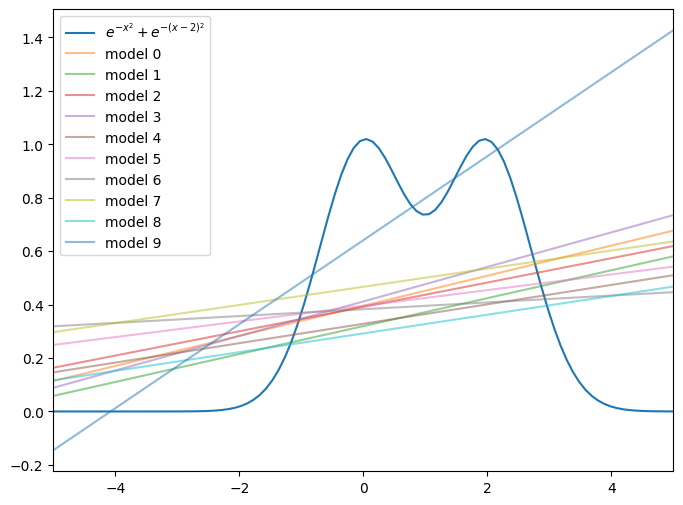

In [ ]:
from sklearn.linear_model import LinearRegression

n_models = 10

plt.figure(figsize=(8, 6))

plt.plot(xs_truth, ys_truth, label=f"${formula}$")

all_ys_model_pred = []

np.random.seed(42_14_2)
for i in range(n_models):
    xs_model, ys_model = sample(25)
    model = LinearRegression()
    model.fit(xs_model.reshape(-1, 1), ys_model)
    ys_model_pred = model.predict(xs_truth.reshape(-1, 1))
    all_ys_model_pred.append(ys_model_pred)
    plt.plot(xs_truth, ys_model_pred, alpha=0.5, label=f"model {i}")

all_ys_model_pred = np.asarray(all_ys_model_pred)

plt.legend()
plt.xlim(xs_truth.min(), xs_truth.max())

plt.show()

Script:
* The ten dashed lines here are linear models trained with 25 samples each.
* On the left where $x \leq -2$, the bias is positive since the predictions are consistently high; all but the orange model 9 are overestimating for all those inputs.
* On the right where $x \geq 3.5$, the bias is even higher and every single one of these sample models overestimates the true average.
* In the middle, the bias is low where the linear models fail to match the peaks in the middle.
* What about the variance?
* This is harder to eyeball, but it looks like it will be lowest around -2 where even the orange model 9 is close to the other models.

## Sample Model Errors by Input $x$


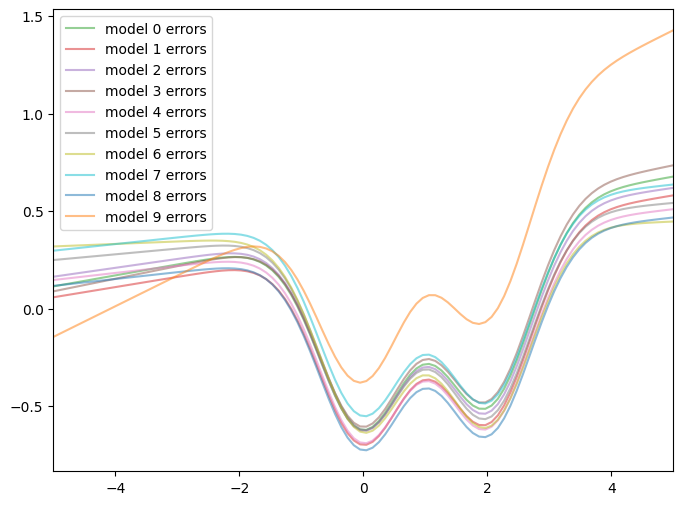

In [ ]:
plt.figure(figsize=(8, 6))

for i in range(n_models):
    plt.plot(xs_truth, all_ys_model_pred[i] - ys_truth, alpha=0.5, color=f"C{i+2}", label=f"model {i} errors")

plt.legend()
plt.xlim(xs_truth.min(), xs_truth.max())

plt.show()

Script:
* Here are the prediction errors of those models.
* The modeling bias will be the average of these curves, and the variance will be the average of the squares.

## Sample Model Errors and Modeling Process Bias by Input $x$


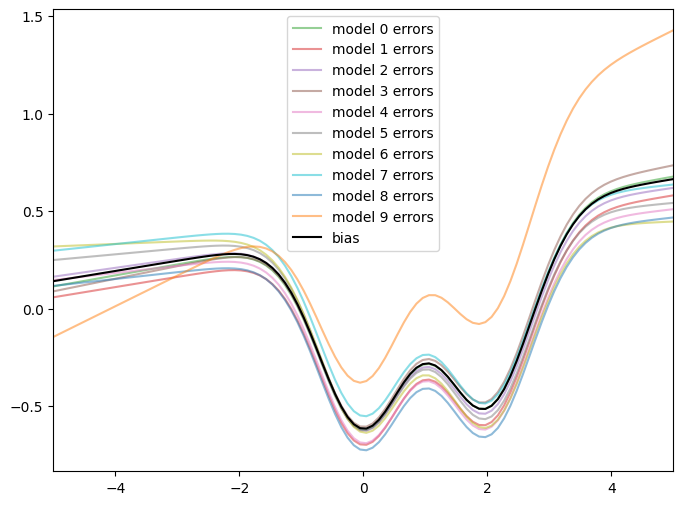

In [ ]:
biases = np.mean(all_ys_model_pred, axis=0) - ys_truth

plt.figure(figsize=(8, 6))

for i in range(n_models):
    plt.plot(xs_truth, all_ys_model_pred[i] - ys_truth, alpha=0.5, color=f"C{i+2}", label=f"model {i} errors")

plt.plot(xs_truth, biases, color="k", label="bias")

plt.legend()
plt.xlim(xs_truth.min(), xs_truth.max())

plt.show()

Script:
* Here is the bias superimposed on those modeling errors.
* Overall, it is right in the middle of the errors, though you can see it move more from the larger outliers.

## Sample Model Errors and Modeling Process Variance by Input $x$


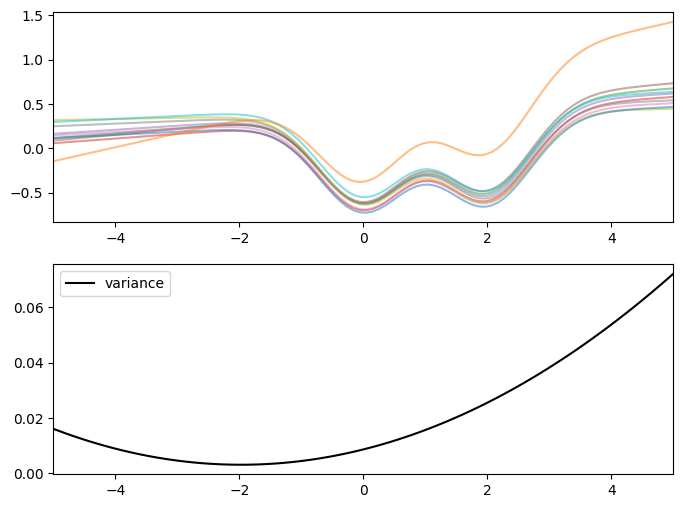

In [ ]:
variances = np.var(all_ys_model_pred, axis=0)

plt.figure(figsize=(8, 6))

plt.subplot(2, 1, 1)

for i in range(n_models):
    plt.plot(xs_truth, all_ys_model_pred[i] - ys_truth, alpha=0.5, color=f"C{i+2}", label=f"model {i} errors")

# plt.legend()
plt.xlim(xs_truth.min(), xs_truth.max())

plt.subplot(2, 1, 2)

plt.plot(xs_truth, variances, color="k", label="variance")

plt.legend()
plt.xlim(xs_truth.min(), xs_truth.max())

plt.show()

Script:
* And here is the variance of the model with the lowest variance by -2 as predicted from the previous charts.

Script: (faculty on screen)
* Bias and variance are core concepts to understand modeling processes.
* These visualizations should give you a clear idea how they work now.